# One-sided quasi-normal mode above a substrate

This example studies a slab waveguide separated from a higher-index substrate by a
low-index gap. The right boundary is outgoing, so the guided slab mode can radiate
into the substrate and becomes a one-sided quasi-normal, or leaky, mode.

We calculate:

1. the real and imaginary parts of the effective index as the slab-substrate
   separation changes;
2. the complex field profile of a moderately leaky mode;
3. the effective index as a function of vacuum wavenumber.

REMSOL uses \(k_0 = \omega/c = 2\pi/\lambda\) as the argument named
\(\mathtt{omega}\). Lengths are expressed in micrometers in this example.

## Imports and structure definition

The layer sequence is

\[
\text{air }(n=1)
\;|\;
\text{slab }(n=2,\ d=0.6)
\;|\;
\text{air gap }(n=1,\ d=s)
\;|\;
\text{substrate }(n=2.2).
\]

The air side keeps the default semi-infinite boundary condition. Only the
substrate side is set to outgoing. With REMSOL's spatial propagation convention,
a passive one-sided leaky mode has
\(\operatorname{Im}(n_\mathrm{eff}) > 0\).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import remsol as rs

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

WAVELENGTH = 1.55
OMEGA = 2.0 * np.pi / WAVELENGTH
POLARIZATION = rs.Polarization.TE


def one_sided_slab(separation):
    structure = rs.MultiLayer(
        [
            rs.Layer(1.0, 2.0),
            rs.Layer(2.0, 0.6),
            rs.Layer(1.0, float(separation)),
            rs.Layer(2.2, 2.0),
        ]
    )
    structure.set_right_boundary(rs.BoundaryCondition.Outgoing)
    return structure


def solve_te0(structure, omega):
    mode = structure.complex_neff(omega, polarization=POLARIZATION, mode=0)
    if mode is None:
        raise RuntimeError(f"No TE0 leaky mode found at omega={omega:.4f}")
    return mode

## Refractive-index profile

The thicknesses assigned to the first and last layers only set the plotting
window; those layers remain semi-infinite in the mode calculation.

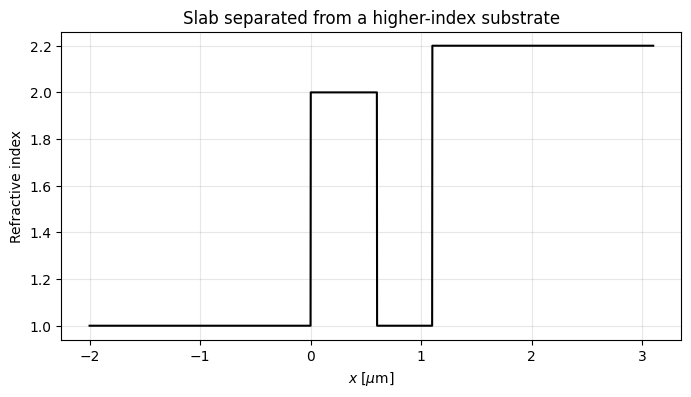

In [2]:
reference_structure = one_sided_slab(separation=0.5)
index_profile = reference_structure.index()

fig, ax = plt.subplots()
ax.plot(index_profile.x, index_profile.n, color="black")
ax.set(
    xlabel=r"$x\;[\mu\mathrm{m}]$",
    ylabel="Refractive index",
    title="Slab separated from a higher-index substrate",
)
plt.show()

## Effective index versus slab-substrate separation

The adaptive complex search is used by omitting explicit real and imaginary
search ranges. The separation sweep stops before the leakage reaches the
real-axis fallback floor, allowing the imaginary part to be displayed directly
on a logarithmic scale.

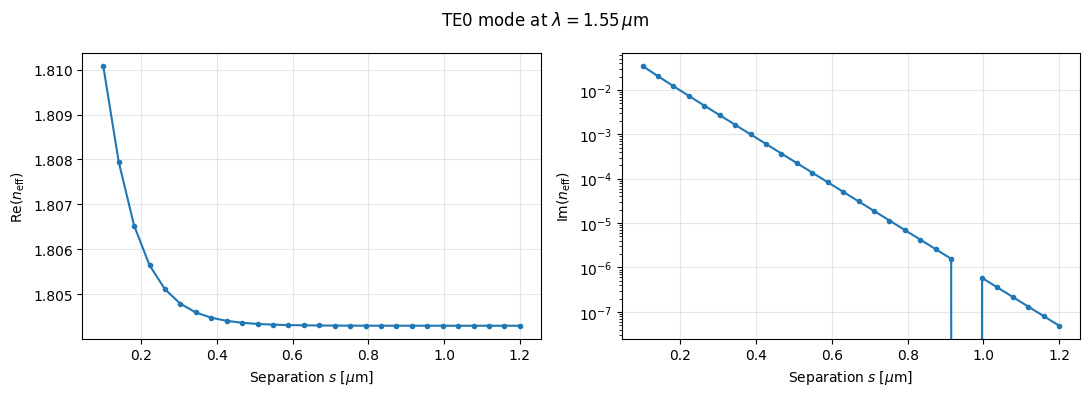

In [3]:
separations = np.linspace(0.1, 1.2, 28)
separation_modes = np.asarray(
    [
        solve_te0(one_sided_slab(separation), OMEGA)
        for separation in separations
    ]
)
re_neff_separation = separation_modes[:, 0]
im_neff_separation = separation_modes[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(separations, re_neff_separation, "o-", markersize=3)
axes[0].set(
    xlabel=r"Separation $s\;[\mu\mathrm{m}]$",
    ylabel=r"$\operatorname{Re}(n_\mathrm{eff})$",
)
axes[1].semilogy(separations, im_neff_separation, "o-", markersize=3)
axes[1].set(
    xlabel=r"Separation $s\;[\mu\mathrm{m}]$",
    ylabel=r"$\operatorname{Im}(n_\mathrm{eff})$",
)
fig.suptitle(rf"TE0 mode at $\lambda={WAVELENGTH}\,\mu\mathrm{{m}}$")
fig.tight_layout()
plt.show()

Increasing the gap suppresses tunnelling into the substrate. Therefore
\(\operatorname{Im}(n_\mathrm{eff})\) decreases rapidly, while the real part
approaches the effective index of the isolated air-clad slab.

## Field profile of a moderately leaky mode

A separation of \(0.3\,\mu\mathrm{m}\) gives visible leakage without placing the
mode extremely deep in the complex plane. For TE polarization, \(E_y\) is the
nonzero electric-field component. The default maximum-field normalization is
used.

The outgoing field is not square-integrable in the semi-infinite substrate.
The plot therefore shows the finite window selected by the exterior layer
thicknesses.

neff = 1.80480994 + 2.81219349e-03j at separation 0.30 um


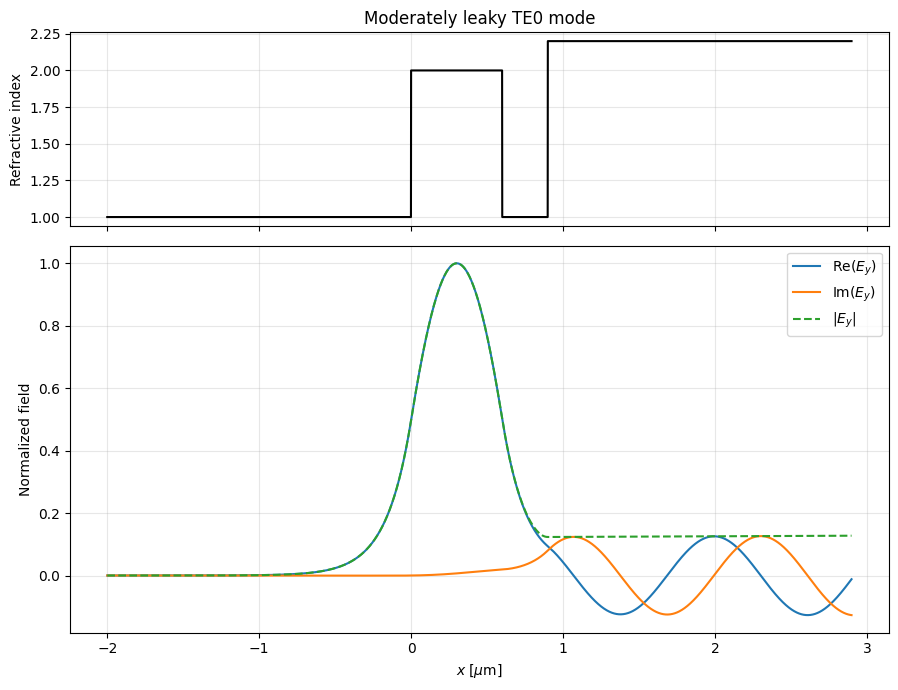

In [4]:
field_separation = 0.3
field_structure = one_sided_slab(field_separation)
re_neff, im_neff = solve_te0(field_structure, OMEGA)
field = field_structure.complex_field(OMEGA, polarization=POLARIZATION)

x = np.asarray(field.x)
ey = np.asarray(field.Ey)
field_index = field_structure.index()

print(
    f"neff = {re_neff:.8f} + {im_neff:.8e}j "
    f"at separation {field_separation:.2f} um"
)

fig, axes = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True, gridspec_kw={"height_ratios": [1, 2]}
)
axes[0].plot(field_index.x, field_index.n, color="black")
axes[0].set(ylabel="Refractive index", title="Moderately leaky TE0 mode")

axes[1].plot(x, np.real(ey), label=r"$\operatorname{Re}(E_y)$")
axes[1].plot(x, np.imag(ey), label=r"$\operatorname{Im}(E_y)$")
axes[1].plot(x, np.abs(ey), "--", label=r"$|E_y|$")
axes[1].set(xlabel=r"$x\;[\mu\mathrm{m}]$", ylabel="Normalized field")
axes[1].legend()
fig.tight_layout()
plt.show()

## Effective index versus vacuum wavenumber

We now keep the geometry fixed at a \(0.5\,\mu\mathrm{m}\) separation and sweep
the API parameter \(\mathtt{omega}=k_0\). The material indices are treated as
nondispersive; a material model would need to update them at every frequency if
dispersion were required.

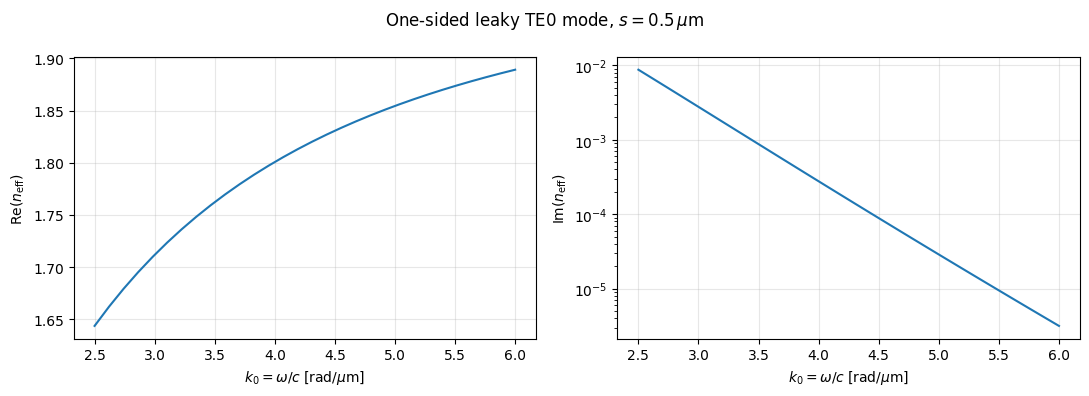

In [5]:
frequency_structure = one_sided_slab(separation=0.5)
omegas = np.linspace(2.5, 6.0, 30)
omega_modes = np.asarray(
    [solve_te0(frequency_structure, omega) for omega in omegas]
)
re_neff_omega = omega_modes[:, 0]
im_neff_omega = omega_modes[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(omegas, re_neff_omega)
axes[0].set(
    xlabel=r"$k_0=\omega/c\;[\mathrm{rad}/\mu\mathrm{m}]$",
    ylabel=r"$\operatorname{Re}(n_\mathrm{eff})$",
)
axes[1].semilogy(omegas, im_neff_omega)
axes[1].set(
    xlabel=r"$k_0=\omega/c\;[\mathrm{rad}/\mu\mathrm{m}]$",
    ylabel=r"$\operatorname{Im}(n_\mathrm{eff})$",
)
fig.suptitle(r"One-sided leaky TE0 mode, $s=0.5\,\mu\mathrm{m}$")
fig.tight_layout()
plt.show()

The real part increases as the mode becomes more confined at larger
\(k_0\). Over this interval the imaginary part decreases, indicating weaker
coupling through the fixed physical gap. For a passive one-sided outgoing mode,
all reported imaginary parts should remain nonnegative, up to numerical
roundoff near the real-axis fallback.